NOTE: This is lecture is meant to be viewed as an .ipynb ( Python Jupyter Notebook esp. in Google Colab: https://drive.google.com/file/d/1ENhMwI1cvXYq1miSsYHSZrh5g6efG3WG/view?usp=sharing )

Please, contact author Robin Yancey for .ipynb or use above link.

# Introduction to Pandas, NumPy, and k-Nearest Neighbors (k-NN)

Pandas and NumPy are foundational Python libraries for data analysis and scientific computing. NumPy provides the core array data structure and fast mathematical operations, while Pandas builds on top of NumPy to offer powerful, flexible data structures for working with labeled, tabular data. These libraries are essential for data cleaning, manipulation, exploration, and modeling in modern data science workflows.

- **NumPy** is the backbone for numerical computation in Python, enabling efficient storage and manipulation of large arrays and matrices of numeric data.
- **Pandas** extends these capabilities by introducing Series (1D labeled arrays) and DataFrames (2D labeled tables), making it easier to work with real-world data that often comes with labels, missing values, and mixed data types.

Understanding the strengths and use cases of each library is crucial for effective data analysis and machine learning.

Data preparation and feature engineering are foundational steps in any machine learning workflow. This notebook provides a comprehensive walkthrough of essential steps in preparing data, engineering features, and applying k-Nearest Neighbors (k-NN) for both regression and classification tasks. Real-world datasets are used throughout, with practical code and visualizations.


---


# Topics Covered

1. **Introduction to Pandas and NumPy:** Overview of the libraries, their roles in data science, and key differences.
2. **Loading Data into Pandas:** How to import data from CSV and other sources, and initial inspection.
3. **First Steps After Loading Data:** Checking data types, missing values, outliers, and basic statistics.
4. **Categorical vs. Continuous Features:** Understanding feature types and their implications for analysis.
5. **Regression vs. Classification:** Distinguishing between prediction tasks and their evaluation.
6. **Exploratory Data Analysis (EDA):** Visualizing and summarizing data to uncover patterns and issues.
7. **Transforming Data Features:** Encoding, scaling, and engineering features for modeling.
8. **Extracting and Selecting Features:** Methods for selecting columns and preparing data for modeling.
9. **Feature Construction and Encoding:** Creating new features and encoding categorical variables.
10. **Working with Real Datasets:** Examples using vertebrae and missed appointment data.
11. **Unbalanced and Dirty Data:** Handling class imbalance and data quality issues.
12. **Regression and k-NN Examples:** Practical modeling with regression and k-nearest neighbors, including visualizations.
13. **Generalization, Overfitting, and Model Complexity:** Concepts for robust modeling.
14. **Summary and Self-Assessment:** Key takeaways and review questions to reinforce learning.


## Table of Contents
1. [Loading Data into Pandas](#loading)
2. [Understanding and Examination of Data Set](#examination)
3. [Data Preprocessing](#preprocess)
4. [Target Column Outcomes](#target)
5. [Obtaining Numerical Features from Categorical Columns](#categorical)
6. [Mapping of Ordinal Features](#ordinal)
7. [Construction Features](#construction)
8. [Regression](#regression)
9. [Generalization, Overfitting, and Underfitting](#generalization)
10. [Model Complexity and Dataset Size](#complexity)
11. [k-Nearest Neighbors (Regression)](#knnreg)
12. [k-Nearest Neighbors (Classification)](#knnclass)


---


## Pandas vs. NumPy
NumPy and Pandas are often used together, but they serve different purposes:
- **NumPy** provides fast, memory-efficient arrays and basic numerical operations. It is ideal for mathematical and logical operations on homogeneous numerical data, such as vectors, matrices, and higher-dimensional arrays. NumPy arrays are the foundation for most scientific computing in Python.
- **Pandas** builds on NumPy, adding labeled, heterogeneous data structures (Series, DataFrame) and powerful data manipulation tools. Pandas is designed for working with tabular data (like spreadsheets or SQL tables), where columns can have different types and labels are important for indexing and alignment.

Key differences:
- NumPy arrays are always homogeneous (all elements must be the same type), while Pandas DataFrames can hold columns of different types (e.g., integers, floats, strings, dates).
- Pandas provides rich functionality for handling missing data, aligning data from different sources, and reshaping or pivoting tables.
- NumPy is best for numerical computation and linear algebra; Pandas is best for data wrangling, cleaning, and analysis.

$\text{NumPy: Fast, efficient, homogeneous arrays}$

$\text{Pandas: Labeled, heterogeneous, tabular data}$


In [ ]:
# Core libraries for data analysis, visualization, and modeling
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")

# All datasets live in this folder (adjust the path if you store them elsewhere)
DATA_DIR = "drive_data"

**Code Explanation:**
This cell imports the libraries used throughout the notebook:
1. **NumPy (`np`)**: Efficient numerical computing with arrays and mathematical operations.
2. **Pandas (`pd`)**: Built on top of NumPy, provides high-level data structures (DataFrames, Series) and data analysis tools.
3. **Matplotlib / Seaborn**: Plotting libraries for visualizing distributions, relationships, and model results.
4. **scikit-learn**: Tools for preprocessing, model training, and evaluation (linear regression, k-NN, cross-validation, metrics).

The `DATA_DIR` variable points to the folder containing the datasets, so every load below uses a single, easy-to-change location.


---


In [ ]:
# NumPy: a fast, homogeneous numeric array
arr = np.array([10, 20, 30, 40, 50])
print("NumPy array:", arr)
print("mean:", arr.mean(), "| std:", round(arr.std(), 3), "| dtype:", arr.dtype)

# Pandas: a labeled, heterogeneous table built on top of NumPy
people = pd.DataFrame({
    "name":   ["Ann", "Bob", "Cara"],         # text
    "age":    [25, 32, 29],                    # int
    "salary": [50000.0, 62000.5, 58000.0],     # float
})
print("\nPandas DataFrame (mixed column types):")
display(people)
print("Column dtypes:")
print(people.dtypes)

NumPy array: [10 20 30 40 50]
mean: 30.0 | std: 14.142 | dtype: int32

Pandas DataFrame (mixed column types):


,name,age,salary
0,Ann,25,50000.0
1,Bob,32,62000.5
2,Cara,29,58000.0


Column dtypes:
name       object
age         int64
salary    float64
dtype: object


**Code Explanation:** A NumPy array holds one homogeneous numeric type and supports fast vectorized math (`.mean()`, `.std()`). A Pandas DataFrame stores columns of *different* types side by side with labels, which is why it is the tool of choice for real tabular data.


### 🧪 Exercise 1: NumPy arrays vs. Pandas structures

Create a NumPy array from the list `[3, 6, 9, 12, 15]` and print its mean and maximum. Then create a Pandas Series of the same values with index `['a','b','c','d','e']` and print the value stored at label `'d'`.

> *Edit the starter cell below. The worked solution is Exercise 1 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
values = [3, 6, 9, 12, 15]
# TODO 1: make a NumPy array from `values`, then print its mean and max
# arr = ...
# TODO 2: make a Pandas Series from `values` with index ['a','b','c','d','e']
#         then print the value at label 'd'
# s = ...

# Loading Data into Pandas
Loading data is the first step in any data science or machine learning workflow. Pandas is a powerful Python library for data manipulation and analysis. It allows us to load, inspect, and preprocess data efficiently.

When loading data, it is important to:
- Check the format and delimiter of the file (e.g., CSV, TXT).
- Handle missing values and data types appropriately.
- Preview the first few rows to understand the structure.

Pandas makes it easy to load data from a variety of sources, including CSV, Excel, SQL databases, JSON, and more. The most common function is `pd.read_csv()`, which reads a comma-separated values (CSV) file into a DataFrame. DataFrames are the primary data structure in Pandas, allowing you to store and manipulate tabular data with labeled rows and columns.

When loading data, you can specify options to handle headers, missing values, data types, delimiters, and encoding. This flexibility is crucial for working with real-world datasets, which often require cleaning and preprocessing before analysis.

**Common options for `pd.read_csv()`:**
- `header`: Row to use as the column names (default is 0, the first row).
- `na_values`: Additional strings to recognize as NA/NaN.
- `dtype`: Specify data types for columns.
- `sep`: Delimiter to use (default is ',').
- `encoding`: File encoding (e.g., 'utf-8').

**Practical tips:**
- Always check the first few rows with `df.head()` and the last few with `df.tail()` to ensure data loaded as expected.
- Use `df.info()` to quickly inspect data types and non-null counts.
- If you encounter errors, check for encoding issues or irregular delimiters.
- For large files, use `nrows` to load a sample, or `chunksize` to process in batches.

Example:
- `pd.read_csv('data.csv')` loads a CSV file.
- `pd.read_excel('data.xlsx')` loads an Excel file.
- `pd.read_sql(query, connection)` loads data from a SQL database.

After loading, always inspect the first few rows with `df.head()` to verify the data was read correctly.

In this example, we load the **Telco Customer Churn** dataset, which contains information about telecom customers and whether they have churned (left the service). We use it as the running example for most of this notebook because it contains a mix of categorical and continuous features, a clear classification target (`Churn`), and a few realistic data-quality issues.


In [ ]:
# Load the Telco Customer Churn dataset
df = pd.read_csv(os.path.join(DATA_DIR, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))

# Preview the first few rows
display(df.head())

# Check for missing values per column
print("Shape:", df.shape)
print("\nMissing values per column:")
print(df.isnull().sum())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Shape: (7043, 21)

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


**Code Explanation:**
This code cell demonstrates the basic data loading process in Pandas:
1. **Load CSV data**: `pd.read_csv()` reads the CSV file into a DataFrame, which is the primary data structure in pandas.
2. **Display first rows**: `df.head()` shows the first 5 rows to give us a quick glimpse of the data structure and contents.
3. **Check shape and missing values**: `df.shape` reports the number of rows and columns, and `df.isnull().sum()` counts the number of missing (null) values in each column, which is crucial for data quality assessment.

This is a fundamental workflow that should be performed whenever loading a new dataset.


## Summary
- Pandas provides powerful, flexible tools for loading data from many sources into DataFrames.
- Careful inspection after loading helps catch issues early, such as missing values, wrong data types, or encoding problems.
- Understanding the options in `pd.read_csv()` and related functions is essential for robust data analysis workflows.
- Always check file format, handle missing values, and preview data structure.

## Review Questions
- What are some common sources from which you can load data into Pandas?
- Which function would you use to load a CSV file? An Excel file?
- What are some important options you can specify in `pd.read_csv()`?
- What are the steps to load a CSV file using pandas?
- Why is it important to inspect your data immediately after loading it?
- Why is it important to check for missing values when loading data?
- How can you preview the first few rows of a DataFrame?


---


### 🧪 Exercise 2: Load a CSV and inspect it

Load the Telco CSV into a new variable `df_ex` using `pd.read_csv`, then print its shape and display the first 3 rows.

> *Edit the starter cell below. The worked solution is Exercise 2 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
# TODO: load the Telco CSV from DATA_DIR into df_ex, then show its shape and first 3 rows
# df_ex = pd.read_csv(os.path.join(DATA_DIR, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))
# print(df_ex.shape)
# display(df_ex.head(3))

# First Steps After Loading Data
When you first load a dataset, it is important to perform some initial checks and exploration to understand its structure and quality. This process helps you identify potential issues early and plan your data cleaning and analysis steps.

**Key checks:**
- **Data types:** Are columns numeric, categorical, or mixed? Are any columns incorrectly typed (e.g., numbers stored as strings)?
- **Missing values:** Are there any missing or null values? Which columns are affected?
- **Outliers:** Are there values that are far outside the expected range?
- **Encoding issues:** Are there strange characters or encoding problems, especially with text data?
- **Target column type:** For supervised learning, is the target variable continuous (regression) or categorical (classification)?
- **Basic statistics:** Use `df.describe()` to get a summary of numeric columns, and `df.info()` for an overview of the DataFrame.
- **Duplicates:** Check for duplicate rows with `df.duplicated().sum()`.
- **Unique values:** Use `df.nunique()` to see how many unique values are in each column.

**Practical advice:**
- Use `df.sample(5)` to view a random sample of rows, which can help spot anomalies.
- For large datasets, use `df.memory_usage(deep=True)` to check memory usage.
- If you see unexpected data types, use `pd.to_numeric()` or `astype()` to convert columns as needed.

These checks help you decide how to clean, transform, and prepare your data for analysis or modeling.


Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
customerID      

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


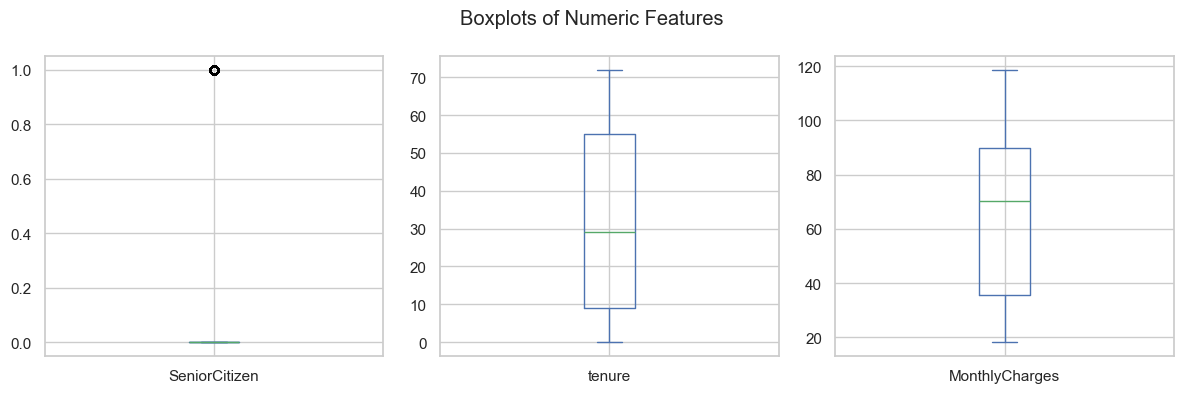

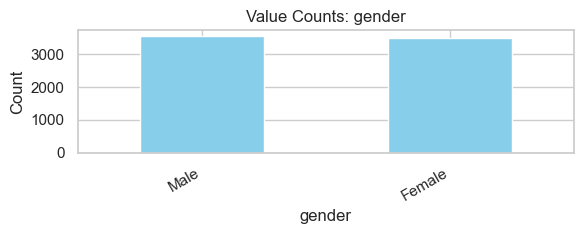

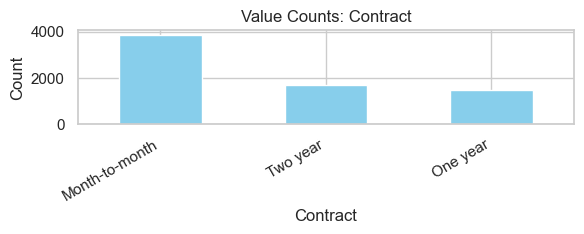

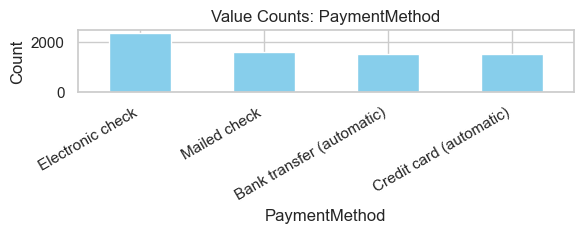

In [ ]:
# Examine the dataset structure and distributions
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

# Full statistical summary (numeric and categorical)
display(df.describe(include="all"))

# Boxplots of the numeric features to reveal spread and outliers
numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols].plot(kind="box", subplots=True, layout=(-1, 3),
                      figsize=(12, 4), sharex=False, sharey=False,
                      title="Boxplots of Numeric Features")
plt.tight_layout()
plt.show()

# Bar charts of value counts for a few categorical features
for col in ["gender", "Contract", "PaymentMethod"]:
    plt.figure(figsize=(6, 2.5))
    df[col].value_counts(dropna=False).plot(kind="bar", color="skyblue")
    plt.title(f"Value Counts: {col}")
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

**Code Explanation:**
This cell performs initial dataset exploration and visualization:

**Data Overview:**
- `df.shape`: Shows the dimensions (rows, columns) of the dataset.
- `df.columns.tolist()`: Lists all column names.
- `df.dtypes`: Shows the data type of each column.
- `df.isnull().sum()`: Counts missing values per column.
- `df.describe(include='all')`: Provides statistical summaries for all columns.

**Visualization:**
- **Numeric columns**: Box plots show distribution, outliers, and quartiles for all numeric features.
- **Categorical columns**: Bar charts show value counts for selected categories.

Note that at this stage `TotalCharges` still appears as a text (object) column rather than numeric — a data-quality issue we will fix in the preprocessing step. This systematic approach helps identify such issues, understand distributions, and spot patterns before proceeding with analysis.


## Summary
- Initial data inspection is critical for understanding the structure and quality of your dataset.
- Checking data types, missing values, outliers, and encoding issues helps prevent problems later in your analysis.
- Use Pandas functions like `info()`, `describe()`, `head()`, and `duplicated()` to quickly assess your data.

## Review Questions
- What are the first things you should check after loading a dataset?
- How can you identify missing values in a DataFrame?
- Why is it important to check data types and unique values?
- What function would you use to get a summary of all columns in a DataFrame?


---


### 🧪 Exercise 3: Quick structural summary

For `df_clean`, print (a) the number of rows, (b) the list of column names, and (c) how many of the columns are numeric.

> *Edit the starter cell below. The worked solution is Exercise 3 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
# TODO: print the row count, the column names, and the number of numeric columns of df_clean
# print("rows:", ...)
# print("columns:", ...)
# print("numeric columns:", ...)

# Understanding and Examination of Data Set
A thorough understanding of your dataset is essential for effective analysis and modeling. This involves more than just looking at the data — it requires investigating the context, quality, and meaning of each feature.

Before building any models, it is crucial to understand the dataset's structure, types of features, and the presence of missing or anomalous values. Key steps include:
- Using `.info()` to check data types, non-null counts, and memory usage.
- Using `.describe()` to get summary statistics for numerical and categorical columns.
- **Check for duplicates:** Use `df.duplicated().sum()` to find duplicate rows, which can bias analysis.
- **Identify outliers:** Use boxplots, z-scores, or the IQR method to detect values far from the norm.
- **Check for inconsistencies:** Look for impossible or illogical values (e.g., negative ages, future dates).
- **Understand feature context:** Know what each column represents, its units, and its relevance to the problem.
- **Consult documentation:** If available, read the data dictionary or metadata to clarify feature meanings.
- **Assess data quality:** Consider completeness, consistency, and accuracy. Missing or incorrect data can lead to misleading results.

**Practical steps:**
- Visualize distributions and relationships to spot anomalies.
- Summarize categorical features with `value_counts()` and continuous features with `describe()`.
- Collaborate with domain experts to interpret ambiguous features.

A thorough examination helps in deciding the right preprocessing and modeling strategies.

$\text{Data quality: completeness, consistency, accuracy}$


In [ ]:
# Concise summary of the DataFrame: dtypes, non-null counts, memory usage
df.info()

# Check for duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Number of unique values per column
print("\nUnique values per column:")
print(df.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Code Explanation:**
- `df.info()` gives a concise technical summary: each column's data type, how many non-null values it has, and the DataFrame's memory usage. This is the quickest way to spot columns with missing values or unexpected types.
- `df.duplicated().sum()` counts fully duplicated rows, which can bias analysis if left in.
- `df.nunique()` reports how many distinct values each column has — useful for telling identifier columns, low-cardinality categoricals, and continuous features apart.


## Summary
- Understanding your dataset's structure, context, and quality is crucial for reliable analysis.
- Checking for duplicates, outliers, and inconsistencies helps ensure data integrity.
- Knowing the meaning of each feature guides effective preprocessing and modeling.
- Use `.info()` and `.describe()` to explore data types, missing values, and summary statistics.
- Identifying issues early helps guide preprocessing and modeling decisions.

## Review Questions
- What does the `.info()` method show about a DataFrame?
- Why is it important to check for duplicates and outliers?
- How can you identify inconsistencies in your data?
- How can you identify missing or anomalous values?
- Why is it important to examine both numerical and categorical columns?
- What resources can help you understand the meaning of each feature?
- What are the three main aspects of data quality?


---


### 🧪 Exercise 4: Duplicates and uniqueness

Print the number of duplicate rows in `df_clean` and the number of unique values in the `PaymentMethod` column.

> *Edit the starter cell below. The worked solution is Exercise 4 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
# TODO: count duplicate rows and unique PaymentMethod values
# print("duplicate rows:", ...)
# print("unique PaymentMethod:", ...)

# Data Preprocessing
Data preprocessing transforms raw data into a clean and usable format for modeling. This step includes handling missing values, encoding categorical variables, and scaling features.

### Handling Missing Values
Check for missing values and decide whether to fill or drop them. In this example, we drop rows with missing values for simplicity. In practice, you may choose to fill missing values with the mean, median, or a constant.

In the Telco dataset, the `TotalCharges` column was loaded as text because a handful of rows contain blank entries (these correspond to brand-new customers with a tenure of 0 months). We first convert the column to numeric — which turns the blanks into `NaN` — and then drop those rows.


In [ ]:
# 'TotalCharges' was read as text because some rows contain blanks.
# Convert it to numeric; invalid/blank entries become NaN.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Inspect the missing values this conversion reveals
missing = df.isnull().sum()
print("Missing values after converting TotalCharges:")
print(missing[missing > 0])

# For simplicity we drop the few rows with missing values.
df_clean = df.dropna().reset_index(drop=True)
print("\nShape before cleaning:", df.shape)
print("Shape after cleaning: ", df_clean.shape)

Missing values after converting TotalCharges:
TotalCharges    11
dtype: int64

Shape before cleaning: (7043, 21)
Shape after cleaning:  (7032, 21)


**Code Explanation:**
- `pd.to_numeric(df['TotalCharges'], errors='coerce')` converts the text column to numbers, replacing any value that cannot be parsed (the blanks) with `NaN`.
- Printing `missing[missing > 0]` confirms exactly which columns — and how many rows — are affected.
- `df.dropna()` removes the rows with missing values, and `reset_index(drop=True)` renumbers the rows so the cleaned DataFrame has a tidy index. We keep the result in `df_clean` and use it for the modeling sections.


## Summary
- Data preprocessing includes handling missing values, encoding categorical variables, and scaling features.
- Proper preprocessing improves model performance and reliability.
- Use exploratory methods to understand distributions, outliers, and feature relationships.
- Data visualization and summary statistics help reveal patterns and issues.
- Early insights guide feature engineering and cleaning.

## Review Questions
- What are common strategies for handling missing values?
- Why do we encode categorical variables?
- Why is feature scaling important for k-NN and similar algorithms?
- What are some ways to visualize feature distributions?
- How can you detect outliers in your data?
- Why is it important to understand feature relationships before modeling?


---


### 🧪 Exercise 5: Fill missing values instead of dropping

Instead of dropping rows with a missing `TotalCharges`, fill them with the column **median**. Start from a copy of the raw `df`, coerce `TotalCharges` to numeric, fill the `NaN`s with the median, and confirm 0 missing values remain.

> *Edit the starter cell below. The worked solution is Exercise 5 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
df_fill = df.copy()
df_fill["TotalCharges"] = pd.to_numeric(df_fill["TotalCharges"], errors="coerce")
# TODO: fill missing TotalCharges with the median, then print how many are still missing
# median_val = ...
# df_fill["TotalCharges"] = ...
# print("missing after fill:", ...)

# Categorical vs. Continuous Features
Understanding the types of features in your dataset is crucial for choosing the right analysis and modeling techniques.

- **Categorical features**: These are variables that take on a limited set of distinct values or categories. Examples include gender (male/female), color (red/blue/green), or product type. Categorical features can be nominal (no natural order, e.g., color) or ordinal (with a natural order, e.g., education level: high school < bachelor < master < PhD).
- **Continuous features**: These are numeric variables that can take any value within a range. Examples include age, income, height, or temperature. Continuous features are typically measured and can have an infinite number of possible values within a given interval.

**Why does this matter?**
- Many machine learning algorithms require numerical input, so categorical features often need to be encoded (e.g., one-hot or ordinal encoding).
- Statistical summaries and visualizations differ: use bar plots for categorical, histograms for continuous.
- Some algorithms (e.g., tree-based models) can handle categorical features natively, but most require conversion.

**Practical examples:**
- Gender (categorical, nominal): Male, Female
- Education (categorical, ordinal): High School, Bachelors, Masters, PhD
- Age (continuous): 18, 25, 42, ...
- Salary (continuous): \$35,000, \$50,000, ...

$\text{Categorical:}\ x \in \{\text{red},\ \text{blue},\ \text{green}\}$

$\text{Continuous:}\ x \in \mathbb{R}$

## Summary
- Categorical features have a limited set of values and may be nominal or ordinal.
- Continuous features are numeric and can take any value within a range.
- Correctly identifying feature types is essential for preprocessing and choosing appropriate analysis methods.

## Review Questions
- What is the difference between a categorical and a continuous feature?
- Give an example of a nominal and an ordinal categorical feature.
- Why do we need to encode categorical features for many machine learning algorithms?
- What types of plots are appropriate for categorical vs. continuous features?


---


In [ ]:
# Programmatically separate categorical from continuous columns
categorical = df_clean.select_dtypes(include="object").columns.tolist()
continuous = df_clean.select_dtypes(include="number").columns.tolist()
print("Categorical columns:", categorical)
print("\nContinuous columns:", continuous)

# A numeric column with very few unique values often behaves like a category
print("\nSeniorCitizen unique values:", df_clean["SeniorCitizen"].unique(),
      "-> stored as numbers but really categorical")

Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Continuous columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

SeniorCitizen unique values: [0 1] -> stored as numbers but really categorical


**Code Explanation:** `select_dtypes` splits columns by storage type — `object` columns are categorical, numeric columns are (usually) continuous. The `SeniorCitizen` example is a reminder that *how a value is stored* and *what it means* can differ: a 0/1 numeric flag is really a category.


### 🧪 Exercise 6: Separate the feature types

From `df_clean`, print the list of object (categorical) columns, and separately find the numeric column that has the **most** unique values.

> *Edit the starter cell below. The worked solution is Exercise 6 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
# TODO: list object columns; find the numeric column with the most unique values
# cats = ...
# most_unique = ...   # hint: select numeric cols, use .nunique().idxmax()
# print("categorical:", cats)
# print("numeric col with most unique values:", most_unique)

# Regression vs. Classification
In supervised machine learning, the type of prediction task determines the choice of algorithms and evaluation metrics.

- **Regression**: The goal is to predict a continuous numeric value, such as house price, temperature, or sales amount. Regression models estimate a function $f(X)$ that maps input features to a real-valued output. Common algorithms include linear regression, decision trees, and support vector regression.
- **Classification**: The goal is to predict a discrete label or category, such as spam/ham, disease/no disease, or digit recognition. Classification models assign input features to one of several classes. Algorithms include logistic regression, decision trees, k-nearest neighbors, and support vector machines.

**Key differences:**
- Regression outputs are continuous; classification outputs are discrete labels.
- Evaluation metrics differ: regression uses mean squared error (MSE), mean absolute error (MAE), etc.; classification uses accuracy, precision, recall, F1-score, etc.
- Some problems can be framed as either regression or classification depending on how the target variable is defined.

**Practical context:**
- Predicting house prices: regression
- Predicting whether a patient has a disease: classification
- Predicting the number of products sold: regression
- Predicting the category of an email (spam/ham): classification

Understanding the distinction is essential for selecting the right approach and interpreting results.

$\text{Regression:}\ y \in \mathbb{R}$
$\text{Classification:}\ y \in \{0, 1, \ldots, K\}$

## Summary
- Regression predicts continuous values; classification predicts discrete categories.
- The choice of task affects algorithm selection and evaluation metrics.
- Some problems can be approached as either regression or classification, depending on the target variable.

## Review Questions
- What is the main difference between regression and classification tasks?
- Give an example of a regression problem and a classification problem.
- What are common evaluation metrics for regression? For classification?
- Can a problem be framed as both regression and classification? Give an example.


---


In [ ]:
# Decide the task type from a target column's dtype / number of unique values
def task_type(series):
    if series.dtype == "object" or series.nunique() <= 10:
        return "classification"   # categorical / few distinct values
    return "regression"           # many distinct numeric values

for col in ["Churn", "TotalCharges", "Contract", "MonthlyCharges"]:
    print(f"{col:15s} -> {task_type(df_clean[col])}")

Churn           -> classification
TotalCharges    -> regression
Contract        -> classification
MonthlyCharges  -> regression


**Code Explanation:** The target's nature decides the task: a categorical or low-cardinality target means **classification**; a continuous numeric target means **regression**. The helper encodes that rule of thumb.


### 🧪 Exercise 7: Decide the task from the target

Using `df_clean`, decide whether predicting `gender` is a regression or classification task, and whether predicting `tenure` is. For each, print the column name, its dtype, its number of unique values, and the task type.

> *Edit the starter cell below. The worked solution is Exercise 7 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
for col in ["gender", "tenure"]:
    s = df_clean[col]
    # TODO: print col, s.dtype, s.nunique(), and whether it is regression or classification
    pass

# Exploratory Data Analysis (EDA)
EDA involves visualizing and summarizing data to understand its structure and relationships. It is a critical first step before modeling, as it helps uncover patterns, spot anomalies, and generate hypotheses.

**Key steps in EDA:**
- **Visualize distributions:** Use histograms, boxplots, and density plots to understand the spread and shape of each feature.
- **Examine relationships:** Use scatter plots, pair plots, and correlation matrices to explore relationships between features and the target variable.
- **Identify missing values and outliers:** Visual tools and summary statistics can help spot data quality issues.
- **Summarize statistics:** Use `df.describe()` for numeric features and `df.describe(include='object')` for categorical features.
- **Group and aggregate:** Use `groupby()` to compare statistics across categories.

**Practical tips:**
- Use `sns.pairplot(df)` (from seaborn) for quick multivariate visualization.
- For large datasets, sample a subset for plotting to improve performance.
- Always look for unexpected patterns or inconsistencies that may indicate data issues.

$\text{EDA: Visualize, summarize, and clean data before modeling}$


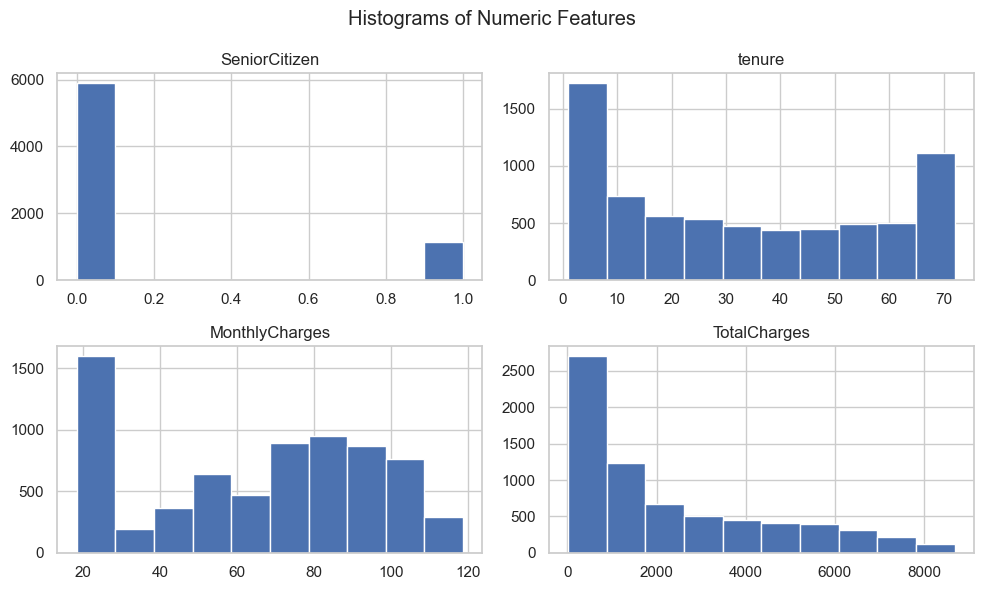

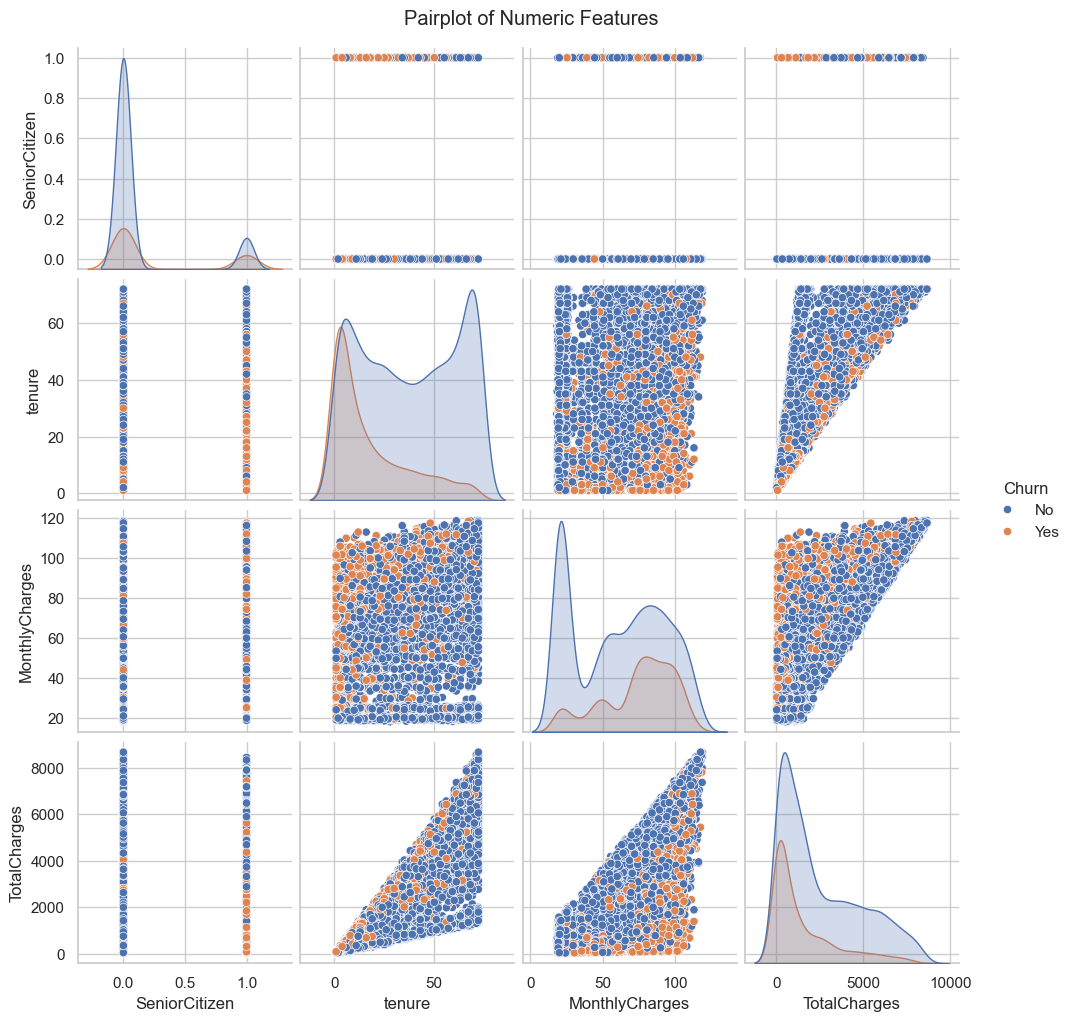

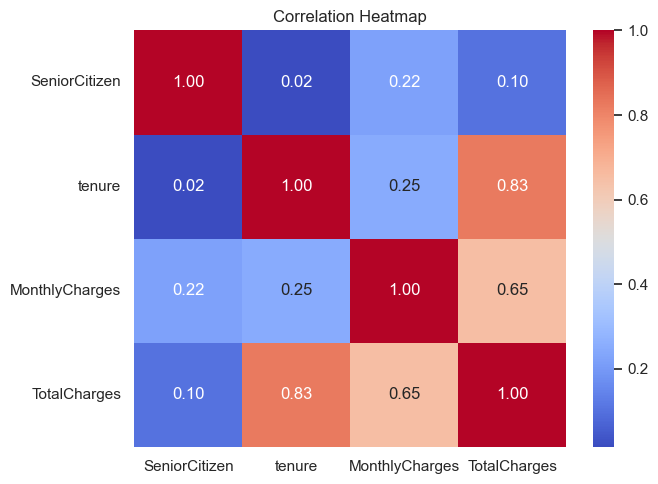

In [ ]:
# Distributions of the numeric features
df_clean.select_dtypes(include="number").hist(figsize=(10, 6))
plt.suptitle("Histograms of Numeric Features")
plt.tight_layout()
plt.show()

# Pairwise relationships between numeric features, coloured by Churn
num_cols = df_clean.select_dtypes(include="number").columns
if len(num_cols) <= 6:
    sns.pairplot(df_clean, vars=num_cols, hue="Churn", diag_kind="kde")
    plt.suptitle("Pairplot of Numeric Features", y=1.02)
    plt.show()

# Correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**Code Explanation:**
This cell demonstrates key EDA (Exploratory Data Analysis) techniques:

**1. Histograms (`df.hist()`):**
- Shows the distribution of all numeric columns in the dataset.
- Helps identify skewness, outliers, and the shape of data distributions.

**2. Pairplot (`sns.pairplot()`):**
- Creates scatter plots for all pairs of numeric variables, coloured by the `Churn` target.
- Shows relationships and correlations between features, and whether the classes separate.
- Only executed if there are 6 or fewer numeric columns to avoid overcrowding.

**3. Correlation Heatmap (`sns.heatmap()`):**
- Visualizes correlation coefficients between numeric variables.
- Uses color coding to show strength and direction of correlations.
- Helps identify highly correlated features that might cause multicollinearity.

These visualizations are essential for understanding your data before building models and can reveal important patterns, outliers, and relationships.


## Summary
- EDA helps you understand your data, spot problems, and generate insights before modeling.
- Visualization and summary statistics are key tools in EDA.
- Identifying issues early saves time and improves model quality.

## Review Questions
- What is the purpose of EDA?
- Name three types of plots useful for EDA.
- How can you identify outliers or missing values during EDA?
- Why is it important to perform EDA before building models?


---


### 🧪 Exercise 8: Histogram and correlation

Plot a histogram of `df_clean['MonthlyCharges']` and print its correlation with `TotalCharges`.

> *Edit the starter cell below. The worked solution is Exercise 8 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
# TODO: histogram of MonthlyCharges; correlation between MonthlyCharges and TotalCharges
# df_clean["MonthlyCharges"].plot(kind="hist", bins=30, title="MonthlyCharges")
# plt.show()
# corr = ...
# print("correlation:", corr)

# Transforming Data Features
Transforming features can make data more meaningful for analysis and modeling. Feature transformation is a key part of data preprocessing and feature engineering.

**Common transformations:**
- **Convert categorical to numerical:** Use encoding techniques such as one-hot encoding, label encoding, or ordinal mapping.
- **Normalize or scale features:** Standardize features to have zero mean and unit variance (z-score), or scale to a fixed range (min-max scaling). This is important for algorithms sensitive to feature scale (e.g., k-NN, SVM).
- **Create new features (feature engineering):** Combine or transform existing features to create more informative variables (e.g., BMI from height and weight, age groups from age).
- **Log or power transforms:** Apply log, square root, or other transformations to reduce skewness or stabilize variance.

**Practical advice:**
- Always fit scaling/encoding on the training set and apply to the test set to avoid data leakage.
- Use `sklearn.preprocessing` for robust, reusable transformations.
- Document your transformations for reproducibility.

$\text{Feature transformation:}\ x' = f(x)$


,gender,gender_num
0,Female,1
1,Male,0
2,Male,0
3,Male,0
4,Female,1


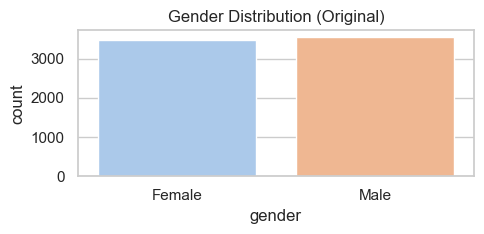

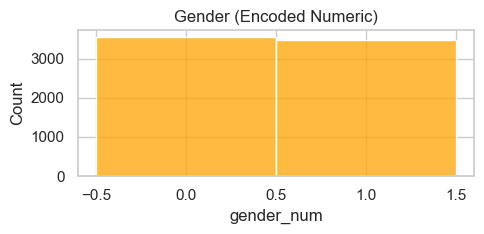

In [ ]:
# Convert the binary categorical 'gender' column to numeric
df_clean["gender_num"] = df_clean["gender"].map({"Male": 0, "Female": 1})
display(df_clean[["gender", "gender_num"]].head())

# Visualize the original categories vs. the encoded values
plt.figure(figsize=(5, 2.5))
sns.countplot(x="gender", data=df_clean, hue="gender", palette="pastel", legend=False)
plt.title("Gender Distribution (Original)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 2.5))
sns.histplot(df_clean["gender_num"], bins=2, discrete=True, color="orange")
plt.title("Gender (Encoded Numeric)")
plt.tight_layout()
plt.show()

**Code Explanation:**
This cell demonstrates categorical feature encoding and visualization:

**1. Label Encoding (`map()`):**
- Converts categorical `gender` values to numeric (Male=0, Female=1) using a dictionary mapping.
- Creates a new column `gender_num` while preserving the original.

**2. Visualization Comparison:**
- **Original data**: `sns.countplot()` shows category counts as a bar chart.
- **Encoded data**: `sns.histplot()` shows the numeric encoding distribution.
- This comparison helps verify the encoding worked correctly.

This approach is useful for binary categorical variables, while one-hot encoding (shown below) is better for nominal categories with more than two values.


## Summary
- Feature transformation prepares data for modeling and can improve model performance.
- Common transformations include encoding, scaling, and feature engineering.
- Proper transformation prevents data leakage and ensures fair model evaluation.

## Review Questions
- Why do we need to transform features before modeling?
- What is the difference between normalization and standardization?
- Give an example of feature engineering.
- Why is it important to avoid data leakage during transformation?


---


### 🧪 Exercise 9: Encode a binary column

Map the `Partner` column (`Yes`/`No`) to `1`/`0` in a new column `Partner_num`, then print its value counts.

> *Edit the starter cell below. The worked solution is Exercise 9 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
# TODO: map Partner Yes->1, No->0 into a new column Partner_num, then print value_counts
# df_clean["Partner_num"] = ...
# print(df_clean["Partner_num"].value_counts())

# Target Column Outcomes
The target column (also called the dependent variable or label) is the variable you want to predict in supervised learning. Understanding its properties is essential for choosing the right modeling approach and evaluation metrics.

For classification problems, we check the balance between classes. For regression, we look at the range and distribution of values.

**Key steps:**
- **Identify the target variable:** Know which column is the target for your prediction task.
- **Check its distribution:** Use `value_counts()` for categorical targets and `hist()` or `describe()` for continuous targets. Imbalanced or skewed distributions may require special handling.
- **Assess class balance:** For classification, check if one class dominates (unbalanced data). For regression, look for outliers or skewness.
- **Understand target meaning:** Know what the target represents and its units or categories.
- **Check for missing or invalid values:** Missing targets can complicate training and evaluation.

**Practical advice:**
- For imbalanced classification, consider resampling techniques or use metrics like ROC-AUC, precision-recall.
- For regression, consider transforming the target if it is highly skewed (e.g., log-transform).
- Always visualize the target distribution before modeling.

In the Telco dataset, the target column is `Churn`, indicating whether a customer has left the service. Visualizing its distribution helps us understand if the dataset is balanced or imbalanced, which can affect model performance.

$\text{Target:}\ y$


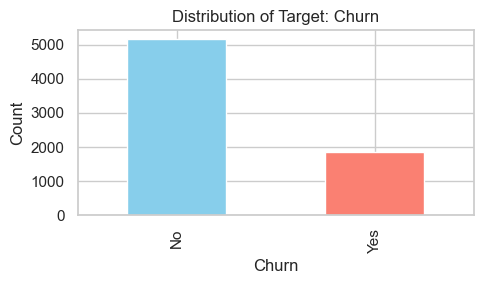

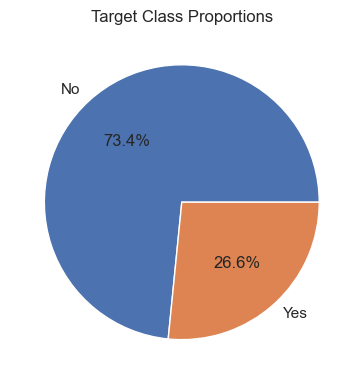

Churn
No     0.734
Yes    0.266
Name: proportion, dtype: float64


In [ ]:
target_col = "Churn"

# Class counts
plt.figure(figsize=(5, 3))
df_clean[target_col].value_counts().plot(kind="bar", color=["skyblue", "salmon"])
plt.title(f"Distribution of Target: {target_col}")
plt.xlabel(target_col)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Class proportions as a pie chart (useful for spotting imbalance)
df_clean[target_col].value_counts(normalize=True).plot.pie(
    autopct="%1.1f%%", figsize=(4, 4), title="Target Class Proportions")
plt.ylabel("")
plt.tight_layout()
plt.show()

print(df_clean[target_col].value_counts(normalize=True).round(3))

**Code Explanation:**
This cell analyzes the target variable (`Churn`):

**1. Target Identification:**
- `target_col = "Churn"` selects the column we want to predict.

**2. Distribution Visualization:**
- A bar chart shows the raw class counts.
- A pie chart shows the class proportions, making class imbalance easy to see.

**3. Class Balance Assessment:**
- Printing the normalized value counts quantifies the imbalance (roughly 73% "No" vs. 27% "Yes").
- Imbalanced datasets can bias models toward the majority class, so identifying this early is important — it influences both model choice and which evaluation metrics are meaningful.


## Summary
- The target column is the variable you want to predict; its properties affect model choice and evaluation.
- Checking the distribution and balance of the target helps identify potential issues early.
- Understanding the target's meaning is crucial for interpreting results.
- Analyzing the target column helps clarify the prediction task.
- Check for class balance (classification) or value range (regression).

## Review Questions
- How do you identify the target column in a dataset?
- Why is it important to check the distribution of the target variable?
- How can you check if your target variable is balanced?
- How does the target type affect your choice of model?
- What problems can arise from an unbalanced target in classification?
- What are some ways to handle missing or skewed target values?


---


### 🧪 Exercise 10: Compute the churn rate

Compute and print the percentage of customers in `df_clean` who churned (`Churn == 'Yes'`).

> *Edit the starter cell below. The worked solution is Exercise 10 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
counts = df_clean["Churn"].value_counts()
print(counts)
# TODO: compute the percentage of 'Yes' and print it
# hint: counts["Yes"] / counts.sum() * 100
# churn_pct = ...
# print(f"Churn rate: {churn_pct:.1f}%")

Churn
No     5163
Yes    1869
Name: count, dtype: int64


# Extracting Feature Columns in Pandas
Selecting the right features (columns) from your DataFrame is a fundamental step in data analysis and modeling. Pandas provides several flexible ways to extract columns by name, position, or condition.

**Common methods:**
- **By name:** `df['col']` or `df[['col1', 'col2']]` selects one or more columns by their names.
- **By position:** `df.iloc[:, idx]` selects columns by integer position (e.g., first column is 0).
- **By label:** `df.loc[:, 'col']` selects columns by label, supporting slicing and boolean indexing.
- **By list:** `df[['col1', 'col2']]` selects multiple columns at once.
- **By data type:** Use `df.select_dtypes(include='number')` to select all numeric columns.

**Practical tips:**
- Use `df.columns` to list all column names.
- For feature selection, you can use boolean masks or drop irrelevant columns with `df.drop()`.
- When preparing data for modeling, separate features (X) from the target (y) to avoid data leakage.

$\text{Feature extraction:}\ X = df[\text{features}]$


,customerID,gender,SeniorCitizen
0,7590-VHVEG,Female,0
1,5575-GNVDE,Male,0
2,3668-QPYBK,Male,0
3,7795-CFOCW,Male,0
4,9237-HQITU,Female,0


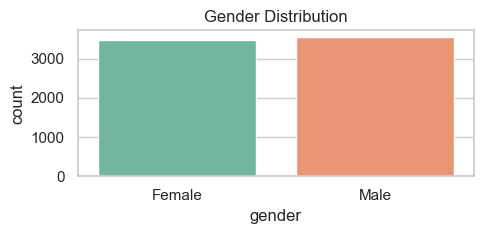

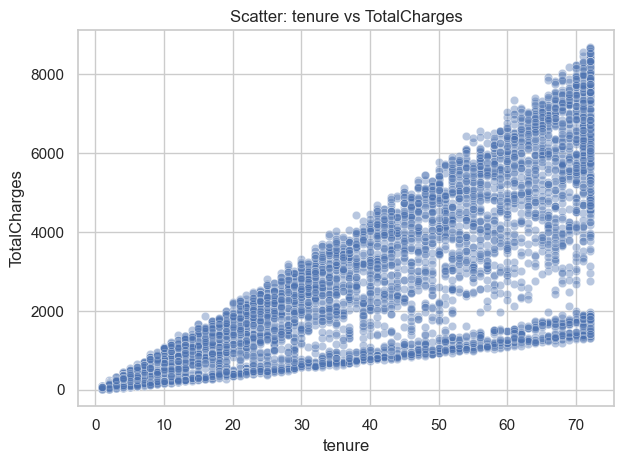

In [ ]:
# Select a single column by integer position
first_col = df_clean.iloc[:, 0]

# Select a single column by name
gender_col = df_clean["gender"]

# Select the first three columns by label
subset = df_clean.loc[:, df_clean.columns[:3]]
display(subset.head())

# Visualize an extracted categorical column
plt.figure(figsize=(5, 2.5))
sns.countplot(x="gender", data=df_clean, hue="gender", palette="Set2", legend=False)
plt.title("Gender Distribution")
plt.tight_layout()
plt.show()

# Scatter plot of two numeric columns (a strongly related pair shows a clear trend)
sns.scatterplot(x="tenure", y="TotalCharges", data=df_clean, alpha=0.4)
plt.title("Scatter: tenure vs TotalCharges")
plt.tight_layout()
plt.show()

**Code Explanation:**
This cell demonstrates various methods for extracting and selecting columns from a DataFrame:

**1. Column Selection Methods:**
- **Position-based**: `df.iloc[:, 0]` selects the first column by index.
- **Name-based**: `df['gender']` selects by column name.
- **Slice selection**: `df.loc[:, df.columns[:3]]` selects the first three columns by label.

**2. Visualization Examples:**
- **Categorical data**: `sns.countplot()` shows the distribution of the `gender` column.
- **Numeric relationships**: a scatter plot relates `tenure` and `TotalCharges` (a strongly correlated pair, so the upward trend is clear).

**3. Data Type Filtering:**
- `df.select_dtypes(include='number')` automatically finds numeric columns, which is handy when separating feature types for appropriate analysis.

This demonstrates the foundation for feature engineering and model preparation workflows.


## Summary
- Pandas offers multiple ways to extract columns by name, position, or type.
- Proper feature selection is essential for effective analysis and modeling.
- Always separate features from the target variable before training models.

## Review Questions
- How do you select a single column by name? Multiple columns?
- What is the difference between `iloc` and `loc`?
- How can you select all numeric columns in a DataFrame?
- Why is it important to separate features from the target variable?


---


### 🧪 Exercise 11: Build a feature matrix

Select the columns `tenure` and `MonthlyCharges` from `df_clean` into a variable `X_ex`, then print its shape and display its first rows.

> *Edit the starter cell below. The worked solution is Exercise 11 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
# TODO: select the two columns into X_ex, then print shape and show head()
# X_ex = df_clean[[...]]
# print(X_ex.shape)
# display(X_ex.head())

# Obtaining Numerical Features from Categorical Columns
Machine learning models typically require numerical input. Categorical features (e.g., `InternetService`) must be converted to numbers.

Two common methods:
- **One-hot encoding**: Creates a new binary column for each category. Best for nominal (unordered) categories. Use `pd.get_dummies()`.
- **Label encoding**: Assigns a unique integer to each category. Best for ordinal (ordered) categories. Use `map()` or `replace()`.

For example, one-hot encoding transforms a column with three categories into three binary columns:
$$ X_{\text{encoded}} = \text{pd.get\_dummies}(X_{\text{categorical}}) $$
This allows models to interpret categorical data correctly without assuming any ordinal relationship.

$\text{One-hot:}\ X_{\text{cat}} \rightarrow X_{\text{num}}$


In [ ]:
# One-hot encode a single nominal column ('InternetService')
df_internet = pd.get_dummies(df_clean, columns=["InternetService"])
display(df_internet.filter(like="InternetService").head())

# One-hot encode every categorical column at once.
# We first drop 'customerID': it is a unique identifier, not a real category,
# and encoding it would create thousands of useless columns.
# drop_first=True removes one category per feature to avoid the dummy-variable trap.
df_encoded = pd.get_dummies(df_clean.drop(columns=["customerID"]), drop_first=True)
print("Original shape:", df_clean.shape)
print("Encoded shape: ", df_encoded.shape)
df_encoded.head()

,InternetService_DSL,InternetService_Fiber optic,InternetService_No
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,False,True,False


Original shape: (7032, 22)
Encoded shape:  (7032, 32)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_num,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,1,False,True,False,False,True,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,0,True,False,False,True,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,True,False,True,False,True


**Code Explanation:**
This cell demonstrates one-hot encoding for categorical variables:

**1. Encoding a single column (`pd.get_dummies(..., columns=['InternetService'])`):**
- Replaces the `InternetService` column with one binary (0/1) column per category (DSL, Fiber optic, No).

**2. Encoding the whole DataFrame:**
- We drop `customerID` first because it is a unique identifier — one-hot encoding it would create thousands of meaningless columns.
- `pd.get_dummies(..., drop_first=True)` then converts every remaining categorical column into binary dummy variables.
- `drop_first=True` removes one category per feature to avoid multicollinearity (the dummy-variable trap).
- Comparing the shapes shows how many new columns the encoding created.

**3. When to Use:**
- Best for nominal categorical variables (no natural order).
- Required for most machine learning algorithms that need numeric input.

This transformation is essential for preparing categorical data for machine learning models.


## Summary / Key Points
- Converting categorical features to numerical is essential for most ML algorithms.
- Common methods include label encoding and one-hot encoding.
- Proper encoding preserves information and avoids introducing bias.

## Review Questions
- What are two common ways to encode categorical variables?
- Why is it important to convert categorical features to numeric?
- How can improper encoding affect your model?


---


### 🧪 Exercise 12: One-hot encode a column

One-hot encode the `PaymentMethod` column with `pd.get_dummies` (use a prefix), and display the first 5 rows of the resulting dummy columns.

> *Edit the starter cell below. The worked solution is Exercise 12 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
# TODO: one-hot encode PaymentMethod and show the first rows of the new columns
# dummies = pd.get_dummies(df_clean["PaymentMethod"], prefix="pay")
# display(dummies.head())

# Mapping of Ordinal Features
Ordinal features are categorical variables with a meaningful order, but not necessarily equal spacing between categories (e.g., education level, contract length). Mapping ordinal features to integers preserves their order and allows models to use this information.

For example, the `Contract` column has three levels:
- 'Month-to-month' < 'One year' < 'Two year'

We can map these to 0, 1, and 2, respectively:

$$ X_{\text{ordinal}} = X_{\text{categorical}}.\text{map}(\{\text{'Month-to-month'}: 0,\ \text{'One year'}: 1,\ \text{'Two year'}: 2\}) $$

This mapping helps models recognize the progression or ranking inherent in the data.

$\text{Ordinal mapping:}\ x \in \{\text{low}, \text{medium}, \text{high}\} \rightarrow \{0, 1, 2\}$


In [ ]:
# 'Contract' has a natural order: Month-to-month < One year < Two year
contract_mapping = {"Month-to-month": 0, "One year": 1, "Two year": 2}
df_clean["ContractOrdinal"] = df_clean["Contract"].map(contract_mapping)
df_clean[["Contract", "ContractOrdinal"]].head()

,Contract,ContractOrdinal
0,Month-to-month,0
1,One year,1
2,Month-to-month,0
3,One year,1
4,Month-to-month,0


**Code Explanation:**
This cell demonstrates ordinal encoding for categorical variables with natural ordering:

**1. Ordinal Mapping:**
- Creates a dictionary mapping contract types to integers: Month-to-month=0, One year=1, Two year=2.
- Uses `df_clean['Contract'].map(contract_mapping)` to apply the mapping.
- Preserves the natural order/hierarchy of contract length.

**2. When to Use Ordinal vs One-Hot:**
- **Ordinal encoding**: Use when categories have natural order (like contract length, education, ratings, sizes).
- **One-hot encoding**: Use when categories are nominal with no inherent order (like colors, countries).

**3. Result Verification:**
- Displaying both the original and encoded columns lets you confirm the mapping worked correctly.

This approach preserves the ordinal relationship between categories, which can be important for model performance and interpretability.


## Summary
- Ordinal features have a natural order that should be preserved when encoding.
- Mapping ordinal categories to integers reflects their ranking.
- Proper handling of ordinal data improves model interpretability and performance.

## Review Questions
- What is an ordinal feature?
- How do you encode ordinal features in pandas?
- Why is it important to preserve order when encoding ordinal data?


---


### 🧪 Exercise 13: Bin and ordinally encode tenure

Bin `tenure` into three ordered groups — `short` (0–12), `medium` (13–48), `long` (49+) — using `pd.cut`, then map them to `0`/`1`/`2` in a new column `tenure_level`. Print the value counts of `tenure_level`.

> *Edit the starter cell below. The worked solution is Exercise 13 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
# TODO: bin tenure into short/medium/long with pd.cut, then map to 0/1/2
# df_clean["tenure_group"] = pd.cut(df_clean["tenure"], bins=[-1, 12, 48, 10_000],
#                                   labels=["short", "medium", "long"])
# df_clean["tenure_level"] = ...
# print(df_clean["tenure_level"].value_counts())

# Crosstab and Confusion Matrix
- `pd.crosstab()` summarizes relationships between two categorical variables.
- A confusion matrix evaluates classification predictions (we use one in the k-NN classification section below).

$\text{Confusion matrix:}\ \begin{bmatrix} \text{TP} & \text{FP} \\ \text{FN} & \text{TN} \end{bmatrix}$


In [ ]:
# Relationship between contract type and churn
display(pd.crosstab(df_clean["Contract"], df_clean["Churn"]))

# Normalized by row to compare churn rates across contract types
display(pd.crosstab(df_clean["Contract"], df_clean["Churn"], normalize="index").round(3))

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


Churn,No,Yes
Contract,,
Month-to-month,0.573,0.427
One year,0.887,0.113
Two year,0.972,0.028


**Code Explanation:**
This cell demonstrates creating crosstab tables to analyze relationships between categorical variables:

**1. Crosstab Analysis:**
- `pd.crosstab(df_clean['Contract'], df_clean['Churn'])` creates a contingency table showing frequency counts for each combination of contract type and churn outcome.
- The second crosstab uses `normalize='index'` to turn the counts into row proportions, making it easy to compare churn *rates* across contract types (month-to-month customers churn far more often).

**2. Use Cases:**
- Analyze relationships between categorical features.
- Identify potential feature interactions.
- Foundation for statistical tests (chi-square, independence tests).
- Useful for data validation and quality checking.

Crosstabs are essential for understanding categorical data relationships before modeling.


---


### 🧪 Exercise 14: Churn rate by gender

Build a row-normalized crosstab of `gender` vs `Churn` so you can compare churn rates between genders. Display it rounded to 3 decimals.

> *Edit the starter cell below. The worked solution is Exercise 14 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
# TODO: crosstab of gender vs Churn, normalized by row
# ct = pd.crosstab(..., ..., normalize="index")
# display(ct.round(3))

# Feature Construction
Feature construction (feature engineering) involves creating new features from existing data to improve model performance. This can reveal hidden patterns or relationships.

Examples include:
- Combining features (e.g., total charges per month = total charges / tenure)
- Extracting date parts (e.g., year, month from a date)
- Creating interaction terms (e.g., product of two features)
- Binning continuous variables into categories

$$ X_{\text{new}} = f(X_1, X_2, \ldots) $$

Thoughtful feature construction can significantly boost the predictive power of machine learning models.


,TotalCharges,tenure,ChargesPerMonth
0,29.85,1,29.850000
1,1889.50,34,55.573529
2,108.15,2,54.075000
3,1840.75,45,40.905556
4,151.65,2,75.825000


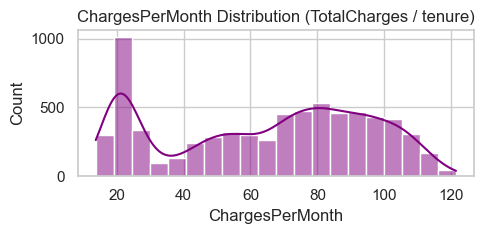

In [ ]:
# Create a new feature: average spend per month of tenure
df_clean["ChargesPerMonth"] = df_clean["TotalCharges"] / df_clean["tenure"]
display(df_clean[["TotalCharges", "tenure", "ChargesPerMonth"]].head())

plt.figure(figsize=(5, 2.5))
sns.histplot(df_clean["ChargesPerMonth"], kde=True, color="purple")
plt.title("ChargesPerMonth Distribution (TotalCharges / tenure)")
plt.tight_layout()
plt.show()

**Code Explanation:**
This cell demonstrates feature engineering by creating a new feature from existing ones:

**1. Feature Construction:**
- `df_clean['ChargesPerMonth'] = df_clean['TotalCharges'] / df_clean['tenure']` creates a new feature capturing average spend per month of tenure.

**2. Visualization:**
- `sns.histplot()` shows the distribution of the new engineered feature, helping assess whether it has useful properties (spread, skewness, etc.).

**3. Feature Engineering Benefits:**
- Can capture relationships between variables that individual features miss.
- May improve model performance by providing more relevant information.
- Examples: BMI from height/weight, ratios, combinations, transformations.

This demonstrates the creative aspect of feature engineering in machine learning workflows.


## Summary
- Feature construction creates new variables that can improve model performance.
- Combining or transforming existing features can reveal hidden patterns.
- Domain knowledge often guides effective feature engineering.

## Review Questions
- What is feature construction?
- Give an example of creating a new feature from existing ones.
- How can feature construction impact model results?


---


### 🧪 Exercise 15: Create a tenure-in-years feature

Create a new feature `tenure_years = tenure / 12` and display the first 5 rows of `tenure` and `tenure_years`.

> *Edit the starter cell below. The worked solution is Exercise 15 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
# TODO: build tenure_years = tenure / 12, then show head of the two columns
# df_clean["tenure_years"] = ...
# display(df_clean[["tenure", "tenure_years"]].head())

# Vertebrae and Missed Appointment Data Examples
Besides the Telco dataset, two further real-world datasets illustrate specific points:
- Use the **vertebrae** dataset for (multi-class) classification.
- Use the **missed appointment** dataset for unbalanced-data examples.

$\text{Unbalanced:}\ \#\text{majority} \gg \#\text{minority}$


In [ ]:
# Vertebrae dataset: space-separated, no header. The last column is the class label.
vertebrae = pd.read_csv(os.path.join(DATA_DIR, "column_3C.dat"), sep=" ", header=None)
print("Shape:", vertebrae.shape)
print("Class distribution:")
print(vertebrae.iloc[:, -1].value_counts())
vertebrae.head()

Shape: (310, 7)
Class distribution:
6
SL    150
NO    100
DH     60
Name: count, dtype: int64


,0,1,2,3,4,5,6
0,63.03,22.55,39.61,40.48,98.67,-0.25,DH
1,39.06,10.06,25.02,29.00,114.41,4.56,DH
2,68.83,22.22,50.09,46.61,105.99,-3.53,DH
3,69.30,24.65,44.31,44.64,101.87,11.21,DH
4,49.71,9.65,28.32,40.06,108.17,7.92,DH


**Code Explanation:**
This cell loads a specialized dataset for classification examples:

**1. Different File Format:**
- Uses `sep=' '` to specify space-separated values instead of comma-separated.
- `header=None` indicates the file has no column headers, so columns are numbered (0, 1, 2, ...).

**2. Dataset Purpose:**
- The vertebrae dataset is commonly used for medical classification problems involving measurements related to spinal-column diagnosis.
- Here the last column holds three classes (DH = Disk Hernia, SL = Spondylolisthesis, NO = Normal), making it a good multi-class classification example.

This demonstrates the flexibility needed when working with real-world datasets that come in various formats.


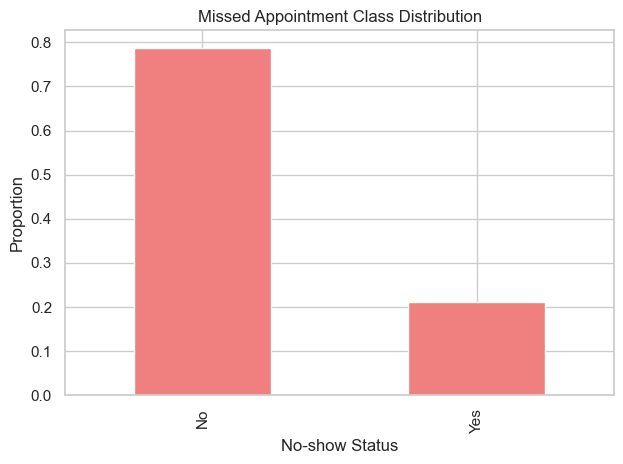

In [ ]:
# Medical appointment no-show dataset: a real, imbalanced classification problem
missed = pd.read_csv(os.path.join(DATA_DIR, "KaggleV2-May-2016.csv"))
missed["No-show"].value_counts(normalize=True).plot(kind="bar", color="lightcoral")
plt.title("Missed Appointment Class Distribution")
plt.xlabel("No-show Status")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

**Code Explanation:**
This cell loads and visualizes an imbalanced classification dataset:

**1. Dataset Loading:**
- Loads a real-world dataset about medical appointment no-shows.

**2. Class Distribution Analysis:**
- `value_counts(normalize=True)` shows proportions rather than raw counts.
- The bar chart makes the class imbalance obvious: the majority class ("No", patients who showed up) dominates the minority class ("Yes", no-shows).

**3. Why This Matters:**
- Imbalanced datasets can bias models toward the majority class.
- They require special techniques: resampling, different metrics (precision/recall), or cost-sensitive learning.

This example prepares you for real-world data science challenges where perfect class balance is rare.


---


### 🧪 Exercise 16: Class distribution of the vertebrae data

For the `vertebrae` dataset, print the class distribution (value counts) of the last column, and the proportion of each class.

> *Edit the starter cell below. The worked solution is Exercise 16 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
# TODO: value counts and proportions of the last vertebrae column
# last = vertebrae.iloc[:, -1]
# print(last.value_counts())
# print(last.value_counts(normalize=True).round(3))

# Unbalanced Data Definition
Unbalanced data occurs when one class is much more frequent than others.

$\text{Unbalanced:}\ P(y=0) \gg P(y=1)$


In [ ]:
# Measure the class imbalance of the Churn target
counts = df_clean["Churn"].value_counts()
ratio = counts.max() / counts.min()
print(counts)
print(f"\nMajority/minority ratio: {ratio:.2f} : 1   (a ratio well above 1 means imbalance)")

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Majority/minority ratio: 2.76 : 1   (a ratio well above 1 means imbalance)


**Code Explanation:** The majority/minority ratio is a quick numeric measure of imbalance. The Telco target is roughly 73% / 27%, a ratio near 2.8 : 1 — imbalanced enough that plain accuracy can be misleading.


### 🧪 Exercise 17: Measure class imbalance

Compute the majority/minority class ratio of the missed-appointment `No-show` target.

> *Edit the starter cell below. The worked solution is Exercise 17 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
# TODO: compute the majority/minority ratio of missed["No-show"]
# vc = missed["No-show"].value_counts()
# ratio = ...
# print(vc)
# print("ratio:", ratio)

# Dirty Data and P-Hacking Defined
- **Dirty data**: Data with errors, inconsistencies, or missing values.
- **P-hacking**: Manipulating data or analysis to obtain statistically significant results.

$\text{Dirty data:}\ x\ \text{contains errors or noise}$
$\text{P-hacking:}\ \text{manipulate analysis for significance}$


---


In [ ]:
# Detect data-quality problems in the appointment data
print("Age range:", missed["Age"].min(), "to", missed["Age"].max())
print("Rows with impossible age (< 0):", int((missed["Age"] < 0).sum()))
print("Rows with suspicious age (> 100):", int((missed["Age"] > 100).sum()))

# In Telco, blank TotalCharges values were dirty data we cleaned earlier:
raw_tc = pd.to_numeric(
    pd.read_csv(os.path.join(DATA_DIR, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))["TotalCharges"],
    errors="coerce")
print("Blank TotalCharges entries in the raw Telco data:", int(raw_tc.isna().sum()))

Age range: 0 to 115
Rows with impossible age (< 0): 0
Rows with suspicious age (> 100): 3
Blank TotalCharges entries in the raw Telco data: 11


**Code Explanation:** Dirty data shows up as impossible or implausible values. Here we scan ages for impossible (`< 0`) and suspicious (`> 100`) values, and re-confirm the blank `TotalCharges` entries that we cleaned in preprocessing. Spotting these *before* modeling prevents misleading results.


### 🧪 Exercise 18: Detect dirty data

In the missed-appointment data, count how many rows have an `Age` greater than 100 (suspicious) and how many have an `Age` below 0 (impossible).

> *Edit the starter cell below. The worked solution is Exercise 18 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
# TODO: count rows with Age > 100 and rows with Age < 0
# print("age > 100:", ...)
# print("age < 0:", ...)

# Regression
Regression is a supervised learning technique used to predict a continuous outcome variable.

$y = f(X) + \epsilon$

Linear regression models the relationship between a dependent variable $y$ and one or more independent variables $X$. The general form of a linear regression model is:
$$ y = Xw + b $$
where:
- $y$ is the target variable
- $X$ is the feature matrix
- $w$ is the vector of coefficients (weights)
- $b$ is the intercept (bias)

The coefficients represent the change in $y$ for a one-unit change in the corresponding feature, holding other features constant.


Coefficients: {'tenure': 65.414, 'MonthlyCharges': 35.879}
Intercept: -2162.432
R^2 on full data: 0.895


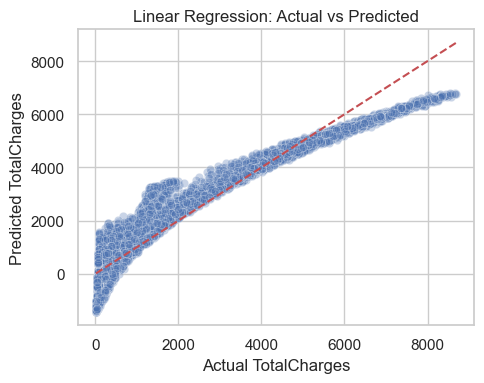

In [ ]:
# Predict a customer's TotalCharges from their tenure and monthly charges
X = df_clean[["tenure", "MonthlyCharges"]]
y = df_clean["TotalCharges"]

model = LinearRegression()
model.fit(X, y)
print("Coefficients:", dict(zip(X.columns, model.coef_.round(3))))
print("Intercept:", round(model.intercept_, 3))
print("R^2 on full data:", round(model.score(X, y), 4))

y_pred = model.predict(X)
plt.figure(figsize=(5, 4))
sns.scatterplot(x=y, y=y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.xlabel("Actual TotalCharges")
plt.ylabel("Predicted TotalCharges")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()

**Code Explanation:**
This cell demonstrates linear regression modeling and evaluation:

**1. Data Preparation:**
- `X` holds the feature columns (`tenure`, `MonthlyCharges`) and `y` is the continuous target (`TotalCharges`).
- Separating features from the target prevents data leakage.

**2. Model Training:**
- `LinearRegression()` creates the model and `model.fit(X, y)` trains it.
- `model.coef_` and `model.intercept_` give the learned weights and bias; `model.score(X, y)` reports the $R^2$.

**3. Prediction and Visualization:**
- The scatter plot of actual vs predicted values shows model performance — points near the dashed diagonal (y = x) indicate accurate predictions.

This demonstrates the basic machine learning workflow: data preparation → model training → prediction → evaluation.


## Key Points
- Regression predicts continuous outcomes based on input features.
- Model evaluation uses metrics like RMSE, MAE, or $R^2$.
- Data preparation and feature selection are critical for good regression results.

## Review Questions
- What is the difference between regression and classification?
- Name two metrics for evaluating regression models.
- Why is feature selection important in regression?


---


### 🧪 Exercise 19: Fit a linear regression

Fit a `LinearRegression` predicting `MonthlyCharges` from `tenure` and `TotalCharges` on `df_clean`. Print the R² and the learned coefficients.

> *Edit the starter cell below. The worked solution is Exercise 19 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
# TODO: fit LinearRegression with y=MonthlyCharges, X=[tenure, TotalCharges]
# Xr = df_clean[["tenure", "TotalCharges"]]
# yr = df_clean["MonthlyCharges"]
# m = LinearRegression().fit(Xr, yr)
# print("R^2:", m.score(Xr, yr))
# print("coef:", m.coef_)

# Generalization, Overfitting, and Underfitting
A good model should generalize well to new, unseen data.
- **Generalization**: Model performs well on unseen data.
- **Overfitting**: The model learns noise and details from the training data, performing poorly on new data.
- **Underfitting**: The model is too simple to capture the underlying pattern, resulting in poor performance on both training and test data.

The goal is to minimize the generalization error:
$$ \text{Generalization Error} = \mathbb{E}_{x,y}[(f(x) - y)^2] $$
where $f(x)$ is the model's prediction and $y$ is the true value.

$\text{Overfit:}\ \text{train error} \ll \text{test error}$
$\text{Underfit:}\ \text{train error} \approx \text{test error} \gg 0$


In [ ]:
# Split into training and test sets to measure generalization
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

model.fit(X_train, y_train)
train_mse = mean_squared_error(y_train, model.predict(X_train))
test_mse = mean_squared_error(y_test, model.predict(X_test))
print(f"Train MSE: {train_mse:,.2f}")
print(f"Test  MSE: {test_mse:,.2f}")

Train MSE: 548,335.16
Test  MSE: 518,441.37


**Code Explanation:**
- `train_test_split` holds out 30% of the data as a test set the model never sees during training.
- We refit the linear model on the training set and compare the mean squared error on the training data vs the test data.
- If the train error were far lower than the test error, that would signal overfitting; similar (but high) errors on both would signal underfitting. Here they should be close, indicating the simple linear model generalizes well.


## Key Points
- Generalization is the model's ability to perform well on unseen data.
- Overfitting means the model learns noise; underfitting means it misses patterns.
- Balancing model complexity is key to good generalization.

## Review Questions
- What is overfitting? What is underfitting?
- How can you detect if your model is overfitting?
- What strategies help improve generalization?


---


### 🧪 Exercise 20: Compare train vs test R²

Using the regression data `X` and `y`, split 70/30 (`random_state=0`), fit a `LinearRegression`, and print both the train and test R² to check for overfitting.

> *Edit the starter cell below. The worked solution is Exercise 20 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
# TODO: split X,y; fit; print train and test R^2
# Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
# m = LinearRegression().fit(Xtr, ytr)
# print("train R^2:", ...)
# print("test  R^2:", ...)

# Model Complexity and Dataset Size
Model complexity refers to the capacity of a model to fit a wide variety of functions. More complex models can fit training data better but may overfit if the dataset is small.

- **High bias**: Model is too simple (underfitting).
- **High variance**: Model is too complex (overfitting).
- **Optimal complexity**: Achieves a balance between bias and variance.

The bias-variance tradeoff is expressed as:
$$ \text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error} $$

Larger datasets help reduce variance and improve generalization, especially for complex models.


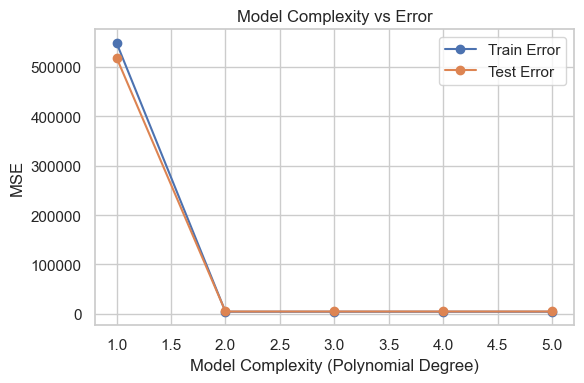

In [ ]:
# Increase model complexity with polynomial features and watch train vs test error
train_errors, test_errors = [], []
degrees = range(1, 6)
for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)
    lin = LinearRegression().fit(X_poly_train, y_train)
    train_errors.append(mean_squared_error(y_train, lin.predict(X_poly_train)))
    test_errors.append(mean_squared_error(y_test, lin.predict(X_poly_test)))

plt.figure(figsize=(6, 4))
plt.plot(degrees, train_errors, marker="o", label="Train Error")
plt.plot(degrees, test_errors, marker="o", label="Test Error")
plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("MSE")
plt.title("Model Complexity vs Error")
plt.legend()
plt.tight_layout()
plt.show()

**Code Explanation:**
- `PolynomialFeatures(degree=d)` expands the features to polynomials of increasing degree, making the linear model progressively more complex.
- For each degree we record the training and test MSE.
- Plotting both curves illustrates the bias-variance tradeoff: training error keeps dropping as complexity grows, while test error eventually stops improving (or rises) once the model starts fitting noise.


## Key Points
- Model complexity should match the amount and quality of data.
- Too complex models overfit; too simple models underfit.
- More data can allow for more complex models without overfitting.

## Review Questions
- How does dataset size affect model complexity?
- What happens if your model is too complex for your data?
- How can you address underfitting?


---


### 🧪 Exercise 21: Degree 1 vs degree 3

Compare polynomial degree 1 vs degree 3 for predicting `y` from `X`. For each degree, fit on `X_train` and print the **test** MSE.

> *Edit the starter cell below. The worked solution is Exercise 21 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
# TODO: for each degree in [1, 3], build PolynomialFeatures, fit, print test MSE
# for d in [1, 3]:
#     poly = PolynomialFeatures(degree=d)
#     Xtr = poly.fit_transform(X_train)
#     Xte = poly.transform(X_test)
#     ...

# k-Nearest Neighbors (Regression)
k-NN regression predicts the target value for a new data point by averaging the target values of its $k$ nearest neighbors in the feature space.

**Intuition:**
- For a new data point, k-NN finds the k closest points in the training data (using a distance metric, usually Euclidean distance).
- The predicted value is the average (mean) of the target values of these k neighbors.
- k-NN is a non-parametric, instance-based method: it does not build an explicit model, but makes predictions based on the training data directly.

**Distance metrics:**
- The most common is Euclidean distance, but others (Manhattan, Minkowski) can be used depending on the problem.
- Features should be scaled (standardized or normalized) so that all contribute equally to the distance calculation.

**Practical considerations:**
- k-NN regression can capture complex, nonlinear relationships, but is sensitive to irrelevant features and the choice of k.
- The choice of $k$ affects the model's bias and variance:
  - Small $k$: low bias, high variance (more sensitive to noise / overfitting).
  - Large $k$: high bias, low variance (smoother predictions / underfitting).
- k-NN can be slow for large datasets, as it computes distances to all training points at prediction time.
- Works best when the number of features is not too large (curse of dimensionality).

The prediction for a new point $x$ is:

$$ \hat{y} = \frac{1}{k} \sum_{i=1}^k y_{(i)} $$

where $y_{(i)}$ are the target values of the $k$ closest points to $x$.


k-NN regression R^2 (test): 0.9987


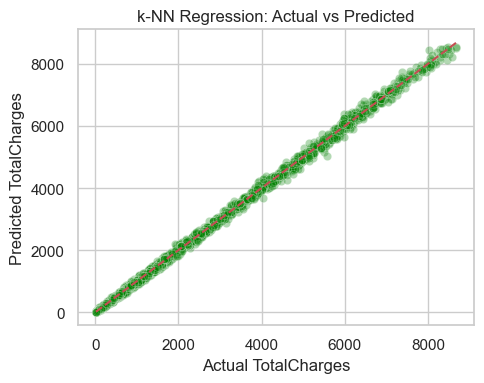

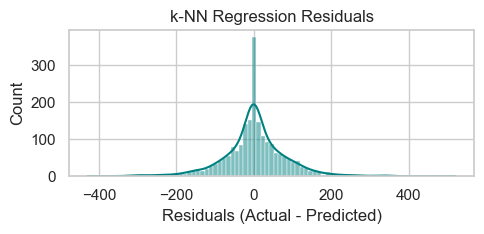

In [ ]:
# k-NN is distance-based, so we standardize the features first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_scaled, y_train)
print("k-NN regression R^2 (test):", round(knn_reg.score(X_test_scaled, y_test), 4))

y_knn_pred = knn_reg.predict(X_test_scaled)

# True vs predicted
plt.figure(figsize=(5, 4))
sns.scatterplot(x=y_test, y=y_knn_pred, alpha=0.3, color="green")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual TotalCharges")
plt.ylabel("Predicted TotalCharges")
plt.title("k-NN Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()

# Residuals
residuals = y_test - y_knn_pred
plt.figure(figsize=(5, 2.5))
sns.histplot(residuals, kde=True, color="teal")
plt.xlabel("Residuals (Actual - Predicted)")
plt.title("k-NN Regression Residuals")
plt.tight_layout()
plt.show()

**Code Explanation:**
This cell demonstrates k-Nearest Neighbors regression with comprehensive evaluation:

**1. Feature Scaling:**
- `StandardScaler` standardizes the features (fit on the training set, applied to the test set). This is essential because k-NN relies on distances, which are dominated by large-scale features otherwise.

**2. Model Setup and Evaluation:**
- `KNeighborsRegressor(n_neighbors=5)` predicts by averaging the target of the 5 nearest training points.
- `knn_reg.score(X_test_scaled, y_test)` returns the $R^2$ on the held-out test set.

**3. Visualization 1 — Predictions vs Reality:**
- Scatter plot of actual vs predicted values; points near the diagonal indicate accurate predictions.

**4. Visualization 2 — Residuals Analysis:**
- `residuals = y_test - y_knn_pred` are the prediction errors; their histogram should be roughly centered at zero. Systematic patterns indicate model limitations.

This comprehensive evaluation approach helps assess both model accuracy and assumptions.


## Summary
- k-NN regression predicts the average value of the k nearest neighbors, making it a simple yet powerful non-parametric method.
- The choice of k and feature scaling are critical for good performance.
- The choice of k and distance metric affects performance.
- Visualizing predictions and residuals helps assess model fit and detect issues.

## Review Questions
- What does k-NN regression predict for a new data point? How does it make predictions?
- Why is feature scaling important for k-NN methods?
- How does the choice of k affect the model's bias and variance?
- How do you choose the value of k?
- What visualizations are useful for evaluating k-NN regression results?


---


### 🧪 Exercise 22: k-NN regression with k=10

Fit a `KNeighborsRegressor` with `k=10` on the scaled features (`X_train_scaled`, `y_train`) and print the test R².

> *Edit the starter cell below. The worked solution is Exercise 22 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
# TODO: fit KNeighborsRegressor(n_neighbors=10) on the scaled training data; print test R^2
# knn10 = KNeighborsRegressor(n_neighbors=10).fit(X_train_scaled, y_train)
# print("k=10 test R^2:", knn10.score(X_test_scaled, y_test))

# k-Nearest Neighbors (Classification)
k-NN classification predicts the most common class among the k nearest neighbors.

**Intuition:**
- For a new data point, k-NN finds the k closest points in the training data (using a distance metric, usually Euclidean distance).
- The predicted class is the majority class (mode) among these k neighbors.
- Like regression, k-NN classification is non-parametric and instance-based: it does not learn explicit parameters, but relies on the training data for predictions.

**Distance metrics:**
- Euclidean distance is most common, but others (Manhattan, Hamming for categorical data) can be used.
- Features should be scaled to ensure fair distance calculations.

**Handling ties:**
- If there is a tie among the k neighbors (e.g., equal votes for two classes), the prediction may be chosen randomly or by another rule (e.g., smallest label).
- Using an odd value for k can help reduce ties in binary classification.

**Practical considerations:**
- k-NN classification can model complex decision boundaries, but is sensitive to noisy data and irrelevant features.
- The choice of k affects the bias-variance tradeoff: small k = low bias, high variance; large k = high bias, low variance.
- k-NN can be computationally expensive for large datasets.
- Not well-suited for high-dimensional data due to the curse of dimensionality.

The prediction for a new point $x$ is:

$$ \hat{y} = \text{mode}(y_{(1)}, \ldots, y_{(k)}) $$

where $y_{(i)}$ are the class labels of the $k$ closest points to $x$.


k-NN classification accuracy (test): 0.7706


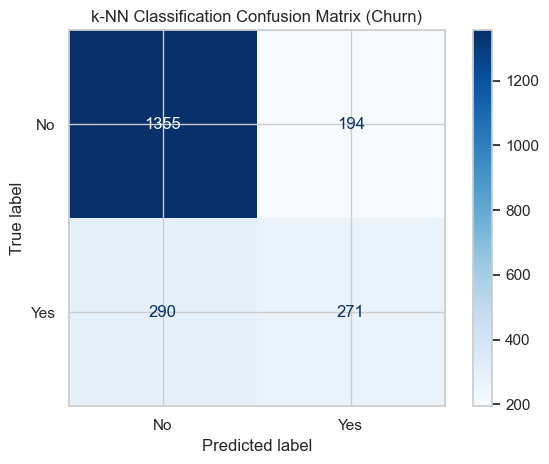

In [ ]:
# Predict Churn from three numeric features
feature_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
X_class = df_clean[feature_cols]
y_class = LabelEncoder().fit_transform(df_clean["Churn"])  # No=0, Yes=1

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.3, random_state=42, stratify=y_class)

# Scale features for the distance-based classifier
scaler_c = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train_c)
X_test_c = scaler_c.transform(X_test_c)

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_c, y_train_c)
print("k-NN classification accuracy (test):", round(knn_clf.score(X_test_c, y_test_c), 4))

y_pred_c = knn_clf.predict(X_test_c)
cm = confusion_matrix(y_test_c, y_pred_c)
ConfusionMatrixDisplay(cm, display_labels=["No", "Yes"]).plot(cmap="Blues")
plt.title("k-NN Classification Confusion Matrix (Churn)")
plt.tight_layout()
plt.show()

**Code Explanation:**
This cell demonstrates k-NN classification with a confusion-matrix evaluation:

**1. Data Preparation:**
- `X_class` holds three numeric features and `y_class` is the encoded `Churn` target (No=0, Yes=1 via `LabelEncoder`).
- `train_test_split(..., stratify=y_class)` keeps the class proportions the same in train and test sets.

**2. Feature Scaling:**
- `StandardScaler` is fit on the training set and applied to the test set, so distances are computed on comparable scales.

**3. Model Training and Evaluation:**
- `KNeighborsClassifier(n_neighbors=5)` predicts each customer's churn by majority vote among its 5 nearest neighbors.
- `knn_clf.score(...)` reports the test accuracy.

**4. Confusion Matrix Analysis:**
- `confusion_matrix()` tabulates true vs predicted classes, and `ConfusionMatrixDisplay` plots it.
- Diagonal cells are correct predictions; off-diagonal cells are errors. On an imbalanced target like this, the confusion matrix is far more informative than accuracy alone.

This corrects a common mistake — running classification on a continuous target — by predicting the genuinely categorical `Churn` label.


## Summary
- k-NN classification assigns the most common class among the k nearest neighbors to a new data point.
- The method is simple, non-parametric, and can model complex decision boundaries.
- The choice of k and proper feature scaling are crucial for effective classification.
- The choice of k and distance metric impacts accuracy and robustness.
- k-NN is sensitive to irrelevant features and the curse of dimensionality.
- Confusion matrices help evaluate classification performance, especially on imbalanced data.

## Review Questions
- How does k-NN classification determine the predicted class for a new sample?
- What are the effects of using a small vs. large k in k-NN classification?
- Why is it important to scale features before applying k-NN?
- What are some limitations of k-NN for classification tasks (e.g., the curse of dimensionality)?
- What tools can you use to evaluate the performance of a k-NN classifier?


---


### 🧪 Exercise 23: k-NN classification with k=7

Fit a `KNeighborsClassifier` with `k=7` on the scaled classification data (`X_train_c`, `y_train_c`) and print the test accuracy.

> *Edit the starter cell below. The worked solution is Exercise 23 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
# TODO: fit KNeighborsClassifier(n_neighbors=7) on the scaled training data; print test accuracy
# clf7 = KNeighborsClassifier(n_neighbors=7).fit(X_train_c, y_train_c)
# print("k=7 accuracy:", clf7.score(X_test_c, y_test_c))

# Finding the Optimal k and Cross Validation
Use cross-validation to select the best k. Cross-validation splits the data into folds, trains on some and validates on the rest, and averages the results to get a robust performance estimate that does not depend on a single train/test split.

$\text{CV Score} = \frac{1}{K} \sum_{i=1}^K \text{Score}_i$


Best k: 20 with 5-fold CV accuracy: 0.7824


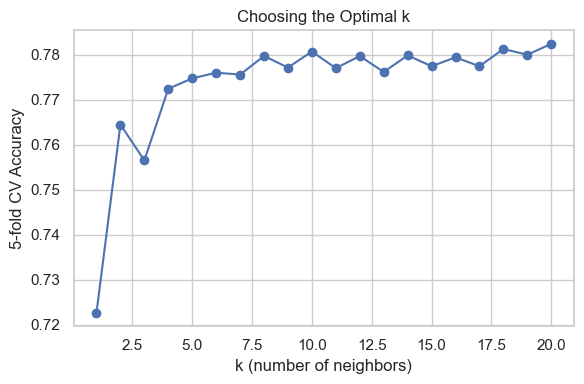

In [ ]:
# Use cross-validation to choose k for the Churn classifier
scaler_cv = StandardScaler()
X_class_scaled = scaler_cv.fit_transform(X_class)

scores = []
ks = range(1, 21)
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_class_scaled, y_class, cv=5).mean()
    scores.append(score)

best_k = int(np.argmax(scores)) + 1
print("Best k:", best_k, "with 5-fold CV accuracy:", round(max(scores), 4))

plt.figure(figsize=(6, 4))
plt.plot(list(ks), scores, marker="o")
plt.xlabel("k (number of neighbors)")
plt.ylabel("5-fold CV Accuracy")
plt.title("Choosing the Optimal k")
plt.tight_layout()
plt.show()

**Code Explanation:**
This cell demonstrates hyperparameter optimization using cross-validation:

**1. Hyperparameter Search:**
- Tests k values from 1 to 20 for the k-NN classifier.

**2. Cross-Validation:**
- `cross_val_score(knn, X_class_scaled, y_class, cv=5)` performs 5-fold cross-validation: it splits the data into 5 parts, trains on 4 and validates on 1, repeating 5 times, and `.mean()` averages the scores for a robust estimate.

**3. Model Selection:**
- `np.argmax(scores)+1` finds the k with the highest CV accuracy, and the plot shows how performance changes with k.

**Why this matters:** cross-validation prevents overfitting to a single split, uses all the data for both training and validation, and yields more reliable estimates of real-world performance — making it standard practice for model selection.


---


### 🧪 Exercise 24: Cross-validate two values of k

Use `cross_val_score` (`cv=5`) on the scaled classification data (`X_class_scaled`, `y_class`) to compare `k=3` and `k=15`. Print the mean CV accuracy for each.

> *Edit the starter cell below. The worked solution is Exercise 24 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
# TODO: for k in [3, 15], compute the 5-fold CV mean accuracy and print it
# for k in [3, 15]:
#     score = cross_val_score(KNeighborsClassifier(n_neighbors=k), X_class_scaled, y_class, cv=5).mean()
#     print(f"k={k}: {score:.4f}")

# K-Fold Cross Validation
K-fold cross-validation splits data into K parts (folds), trains on K-1 of them, tests on the remaining fold, and repeats so that every fold serves as the test set exactly once. The final score is the average across folds.

$\text{CV Score} = \frac{1}{K} \sum_{i=1}^K \text{Score}_i$


---


In [ ]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []
for fold, (tr_idx, te_idx) in enumerate(kf.split(X), start=1):
    m = LinearRegression().fit(X.iloc[tr_idx], y.iloc[tr_idx])
    s = m.score(X.iloc[te_idx], y.iloc[te_idx])
    fold_scores.append(s)
    print(f"Fold {fold}: R^2 = {s:.4f}")
print(f"\nMean R^2 across folds: {np.mean(fold_scores):.4f}")

Fold 1: R^2 = 0.9005
Fold 2: R^2 = 0.9015
Fold 3: R^2 = 0.8961
Fold 4: R^2 = 0.8888
Fold 5: R^2 = 0.8864

Mean R^2 across folds: 0.8947


**Code Explanation:** `KFold` yields train/test index pairs for each fold. We fit a fresh model per fold and record its score; the mean across folds is a more reliable performance estimate than a single split. This is exactly what `cross_val_score` automates.


### 🧪 Exercise 25: Manual K-fold loop

Use `KFold(n_splits=5, shuffle=True, random_state=1)` with a `LinearRegression` on `X`, `y`. Print the R² of each fold and the mean R².

> *Edit the starter cell below. The worked solution is Exercise 25 in `ML_Assessment_Solutions.ipynb`.*


In [ ]:
from sklearn.model_selection import KFold
# TODO: loop over kf.split(X), fit LinearRegression per fold, collect R^2, print each and the mean
# kf = KFold(n_splits=5, shuffle=True, random_state=1)
# scores = []
# for tr, te in kf.split(X):
#     ...

# Summary and Self-Assessment

## Key Takeaways
- **NumPy** provides fast, efficient operations on homogeneous arrays and is the foundation for numerical computing in Python.
- **Pandas** builds on NumPy, offering labeled, heterogeneous data structures (Series, DataFrame) and powerful data manipulation tools.
- Data preparation and feature engineering are foundational for any machine learning workflow.
- Always inspect your data after loading: check types, missing values, outliers, and encoding issues.
- Understanding your dataset, handling missing values, and encoding categorical/ordinal features are essential steps.
- Distinguish between **categorical** and **continuous** features, and between **regression** and **classification** tasks.
- Use **EDA** (Exploratory Data Analysis) to visualize and summarize your data before modeling.
- Transform features as needed: convert categorical to numerical, normalize, and engineer new features.
- Extract features using `iloc`, `loc`, and column names; encode categorical variables with one-hot or ordinal mapping.
- Feature construction and selection can significantly impact model performance.
- Use `pd.crosstab` and confusion matrices to analyze relationships and evaluate classification results.
- Be aware of **unbalanced data**, **dirty data**, and the risks of **p-hacking**.
- Understand the concepts of **generalization**, **overfitting**, and **underfitting**.
- Model complexity and dataset size affect the bias-variance tradeoff.
- **k-Nearest Neighbors** can be used for both regression and classification, but is sensitive to feature scaling and irrelevant features; use cross-validation to select optimal parameters.
- **K-fold cross-validation** is essential for robust model evaluation.

## Review Questions
- What are the main differences between NumPy and Pandas?
- What are the main steps in preparing data for machine learning?
- What are the first things you should check after loading a dataset?
- How do you distinguish between categorical and continuous features?
- How do you convert categorical features to numerical features?
- How do you handle categorical and ordinal features?
- What is the purpose of EDA?
- How do you extract columns from a DataFrame using different methods?
- What is the difference between one-hot encoding and ordinal mapping?
- How do you handle unbalanced data?
- What is p-hacking and why is it problematic?
- Why is feature scaling important, and when is it necessary?
- Explain the concepts of generalization, overfitting, and underfitting.
- How do you detect and address overfitting and underfitting?
- How does model complexity relate to the bias-variance tradeoff?
- What is the bias-variance tradeoff?
- How does k-NN work for regression and classification?
- What are the limitations of k-NN and how can you address them?
- Why is cross-validation important in model selection?
